# Anti-Money Laundering in Bitcoin Transactions

## Study objectives

This study uses the Elliptic Bitcoin transaction graph to:

1. Explore the temporal, class, and graph structure of the dataset.
2. Prepare transaction features and labels without introducing data leakage.
3. Build baseline models for distinguishing licit and illicit transactions.
4. Evaluate models with metrics appropriate for severe class imbalance.
5. Record assumptions, random seeds, dependency versions, and generated artifacts
   so the analysis can be reproduced.

## Dataset

The Elliptic dataset is downloaded separately and is not stored in this
repository. See `docs/dataset.md` for acquisition and placement instructions.

In [2]:
from pathlib import Path # library module for working with file system paths.
import os # library module for interacting with the operating system. 
import platform # library module for getting information about the operating system.
import random # library module for generating random numbers.

import numpy as np # library module for numerical computing with arrays and matrices.
import pandas as pd # library module for data manipulation and analysis.
import sklearn # library module for machine learning and data mining.

RANDOM_SEED = 42 # constant variable for setting the random seed for reproducibility.

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED) # set the PYTHONHASHSEED environment variable to the random seed value.
random.seed(RANDOM_SEED) # set the random seed for the random module.
np.random.seed(RANDOM_SEED) # set the random seed for the numpy module.



In [3]:
# This function automatically locates your project's main folder so your code can safely load files using consistent relative paths, 
# regardless of where your Jupyter notebook was launched.
def find_project_root(start: Path | None = None) -> Path:
    """Find the project root regardless of where Jupyter was launched."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (candidate / "requirements.txt").is_file():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Expected a parent directory containing "
        "'requirements.txt'. Start Jupyter inside this project."
    )

In [4]:
# This code block serves as an environment and dataset validation setup for your project pipeline.
# It ensures your workspace is properly configured and that all required data files exist before executing heavy computations.

# this line calls the find_project_root function to locate the project root 
# directory and assigns it to the PROJECT_ROOT variable.
PROJECT_ROOT = find_project_root() 
# this line constructs the path to the directory where the raw dataset 
# files are expected to be located, based on the project root.
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "elliptic_bitcoin_dataset" 
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

REQUIRED_DATA_FILES = (
    "elliptic_txs_features.csv",
    "elliptic_txs_classes.csv",
    "elliptic_txs_edgelist.csv",
)

missing_files = [
    DATA_DIR / filename
    for filename in REQUIRED_DATA_FILES
    if not (DATA_DIR / filename).is_file()
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Python:       {platform.python_version()}")
print(f"NumPy:        {np.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Random seed:  {RANDOM_SEED}")

if missing_files:
    missing_list = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "Elliptic dataset is incomplete or has not been downloaded.\n"
        f"Expected directory: {DATA_DIR}\n"
        f"Missing files:\n{missing_list}\n"
        "Follow docs/dataset.md to obtain the dataset."
    )

print("Dataset check passed: all required files were found.")

Project root: E:\Machine Leraning\ML Project\AML Crypto Complience
Python:       3.13.5
NumPy:        2.5.2
pandas:       3.0.5
scikit-learn: 1.9.0
Random seed:  42
Dataset check passed: all required files were found.


## 2. Data loading and validation

Load the Elliptic transaction features, labels, and payment-flow edges.
Validate their schemas and relationships before performing analysis or modeling.

In [5]:
# foLLOWING ARE THE PATHS TO THE DATA FILES
FEATURES_PATH = DATA_DIR / "elliptic_txs_features.csv"
CLASSES_PATH = DATA_DIR / "elliptic_txs_classes.csv"
EDGES_PATH = DATA_DIR / "elliptic_txs_edgelist.csv"

# The 166 node features consist of:
# - time_step
# - 93 other local transaction features
# - 72 aggregated one-hop features
LOCAL_TRANSACTION_COLUMNS = [
    f"local_feature_{number:03d}"
    for number in range(1, 94)    
]

AGGREGATE_FEATURE_COLUMNS = [
    f"aggregate_feature_{number:03d}"
    for number in range(1,73)
]

NODE_FEATURE_COLUMNS = [
    "time_step",
    *LOCAL_TRANSACTION_COLUMNS,
    *AGGREGATE_FEATURE_COLUMNS,
]

FEATURE_COLUMNS = [
    "transaction_id",
    *NODE_FEATURE_COLUMNS,
]

print(f"Node features: {len(NODE_FEATURE_COLUMNS)}")
print(f"Raw feature columns including ID: {len(FEATURE_COLUMNS)}")

Node features: 166
Raw feature columns including ID: 167


In [6]:
# following dictionary defines the data types for specific features in the dataset.
feature_dtypes = {
    "transaction_id": "int64",
    "time_step": "int16",
}

# update the feature_dtypes dictionary to include all local transaction and aggregate feature columns with a data type of float32.
feature_dtypes.update({
    column: "float32"
    for column in LOCAL_TRANSACTION_COLUMNS + AGGREGATE_FEATURE_COLUMNS
})

features_df = pd.read_csv(
    FEATURES_PATH,
    header=None,
    names=FEATURE_COLUMNS,
    dtype=feature_dtypes,
)

classes_df = (
    pd.read_csv(
        CLASSES_PATH,
        dtype={
            "txId": "int64",
            "class": "string",
        },
    ).rename(columns={"txId": "transaction_id", "class": "raw_class"})
)

edges_df = (
    pd.read_csv(
        EDGES_PATH,
        dtype={
            "txId1": "int64",
            "txId2": "int64",
        },
    ).rename(columns={"txId1": "source_transaction_id", "txId2": "target_transaction_id"})
)

print(f"Features shape: {features_df.shape}")
print(f"Classes shape: {classes_df.shape}")
print(f"Edges shape: {edges_df.shape}")

Features shape: (203769, 167)
Classes shape: (203769, 2)
Edges shape: (234355, 2)


In [7]:
# This section is responsible for cleaning, validating, and standardizing the transaction labels
# before use them for your AML machine-learning model.

classes_df["raw_class"] = (classes_df["raw_class"].str.strip().str.lower())

LABEL_MAP = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
}

# following line creates a sorted list of unique labels in the classes_df DataFrame 
# that are not present in the LABEL_MAP dictionary.
# (i.e., 1,2, and unknown are recognized labels, 3 or any other label would be unrecognized)
unrecognized_labels = sorted(
    set(classes_df["raw_class"].dropna()) - set(LABEL_MAP)
)
# print(f"Unrecognized labels: {unrecognized_labels}")

# Stop the program if an unexpected label exists
if unrecognized_labels:
    raise ValueError(
        f"Unrecognized labels found in classes_df: {unrecognized_labels}. "
        "Please update the LABEL_MAP dictionary to include these labels."
    )

# Convert raw labels into meaningful labels
classes_df["label"] = classes_df["raw_class"].map(LABEL_MAP)

# Convert label into a categorical variable
classes_df["label"] = pd.Categorical(
    classes_df["label"],
    categories=["licit", "illicit", "unknown"],
)

classes_df["label"].value_counts()

label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

In [8]:
# explicit validation function
# This section is a data-validation gate.
# Its purpose is to make sure the three Elliptic dataset files you loaded earlier
#  are actually the expected/canonical dataset before you allow the ML pipeline to continue.

EXPECTED_TRANSACTION_COUNT = 203_769
EXPECTED_EDGE_COUNT = 234_355
EXPECTED_TIME_STEPS = set(range(1, 50))

EXPECTED_LABEL_COUNTS = {
    "licit": 42_019,
    "illicit": 4_545,
    "unknown": 157_205,
}


def require(condition: bool, message: str) -> None:
    """Raise an understandable error when a dataset condition is not met."""
    if not condition:
        raise ValueError(f"Elliptic dataset validation failed: {message}")


def validate_elliptic_data(
    features: pd.DataFrame,
    classes: pd.DataFrame,
    edges: pd.DataFrame,
) -> None:
    """Validate the canonical Elliptic transaction dataset."""

    require(
        features.shape == (EXPECTED_TRANSACTION_COUNT, 167),
        f"feature table has shape {features.shape}; "
        f"expected ({EXPECTED_TRANSACTION_COUNT}, 167)",
    )

    require(
        len(classes) == EXPECTED_TRANSACTION_COUNT,
        f"class table has {len(classes):,} rows; "
        f"expected {EXPECTED_TRANSACTION_COUNT:,}",
    )

    require(
        edges.shape == (EXPECTED_EDGE_COUNT, 2),
        f"edge table has shape {edges.shape}; "
        f"expected ({EXPECTED_EDGE_COUNT}, 2)",
    )

    require(
        list(features.columns) == FEATURE_COLUMNS,
        "feature columns do not match the expected schema",
    )

    require(
        list(edges.columns)
        == ["source_transaction_id", "target_transaction_id"],
        "edge columns do not match the expected schema",
    )

    feature_duplicates = int(
        features["transaction_id"].duplicated().sum()
    )
    class_duplicates = int(
        classes["transaction_id"].duplicated().sum()
    )
    edge_duplicates = int(edges.duplicated().sum())

    require(
        feature_duplicates == 0,
        f"found {feature_duplicates:,} duplicated feature transaction IDs",
    )
    require(
        class_duplicates == 0,
        f"found {class_duplicates:,} duplicated class transaction IDs",
    )
    require(
        edge_duplicates == 0,
        f"found {edge_duplicates:,} duplicated edges",
    )

    require(
        not features.isna().any().any(),
        "the feature table contains missing values",
    )
    require(
        not classes.isna().any().any(),
        "the class table contains missing values",
    )
    require(
        not edges.isna().any().any(),
        "the edge table contains missing values",
    )

    require(
        np.isfinite(
            features[NODE_FEATURE_COLUMNS].to_numpy(copy=False)
        ).all(),
        "the feature table contains infinite values",
    )

    observed_time_steps = set(
        features["time_step"].astype(int).unique()
    )
    require(
        observed_time_steps == EXPECTED_TIME_STEPS,
        f"time steps are {sorted(observed_time_steps)}; expected 1 through 49",
    )

    feature_ids = pd.Index(features["transaction_id"])
    class_ids = pd.Index(classes["transaction_id"])

    missing_class_ids = feature_ids.difference(class_ids)
    orphan_class_ids = class_ids.difference(feature_ids)

    require(
        missing_class_ids.empty,
        f"{len(missing_class_ids):,} transactions have no class record",
    )
    require(
        orphan_class_ids.empty,
        f"{len(orphan_class_ids):,} class records have no feature row",
    )

    valid_source = edges["source_transaction_id"].isin(feature_ids)
    valid_target = edges["target_transaction_id"].isin(feature_ids)

    require(
        valid_source.all(),
        f"{int((~valid_source).sum()):,} edges have an unknown source",
    )
    require(
        valid_target.all(),
        f"{int((~valid_target).sum()):,} edges have an unknown target",
    )

    observed_counts = {
        str(label): int(count)
        for label, count in classes["label"].value_counts().items()
    }

    require(
        observed_counts == EXPECTED_LABEL_COUNTS,
        f"label counts are {observed_counts}; "
        f"expected {EXPECTED_LABEL_COUNTS}",
    )

    print("Elliptic dataset validation passed.")

validate_elliptic_data(features_df, classes_df, edges_df)

Elliptic dataset validation passed.


In [9]:
# Create the clean transaction table

transaction_df = features_df.merge(
    classes_df[["transaction_id", "label"]],
    on="transaction_id",
    how="left",
    validate="one_to_one"
)

print(f"Transaction table shape: {transaction_df.shape}")
print(f"Edges: {edges_df.shape}")
print()
print(transaction_df['label'].value_counts())



# test the validation function with a modified classes_df to simulate a failure case
# try:
#     validate_elliptic_data(
#         features_df,
#         classes_df.iloc[:-1],
#         edges_df,
#     )
# except ValueError as error:
#     print(error)

Transaction table shape: (203769, 168)
Edges: (234355, 2)

label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


## 3. Exploratory data analysis

This section examines label coverage, temporal behavior, anonymized feature
distributions, and the transaction graph. All analyses are descriptive.

Unknown labels are not assumed to be licit. Any future feature selection must
be performed using training data only.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")


LABEL_COLORS = {
    "licit": "#2E8B57",  # SeaGreen
    "illicit": "#C0392B", # Red
    "unknown": "#7F8C8D"  # Dark Gray
}

# 
LABEL_ORDER = ["licit", "illicit", "unknown"]

In [11]:
# Count each label (i.e. Illecit, licit, unknown)
label_counts = (
    transaction_df["label"]
    .value_counts()
    .reindex(LABEL_ORDER)
    .astype(int)
    )

# label_summary -- table with two columns (i.e. count, percentage_of_all_labels)
label_summary = pd.DataFrame({
    "count": label_counts,
    "percentage_of_all_labels": (
        label_counts / len(transaction_df) * 100
    ).round(3),
})

# print(f"Label Summary: {label_summary}")

# isin() indicate boolean value (licit, illicite = TRUE, unknown = FALSE)
labeled_mask = transaction_df["label"].isin(["licit", "illicit"])
# print(labeled_mask.value_counts())

# Create a subset of the transaction_df DataFrame that only includes rows where the label is either "licit" or "illicit".
labeled_df = transaction_df.loc[labeled_mask].copy()

# Calculate the percentage of illicit transactions among the labeled transactions
illicit_rate_labeled = (labeled_df.eq("illicit").mean() * 100).round(3)

display(label_summary)
print("---------------------------------")
print(f"Total transactions:   {len(transaction_df):,}")
print(f"Labeled transactions: {len(labeled_df):,}")
print(f"Label coverage:        {labeled_mask.mean() * 100:.3f}%")
print(f"Unknown coverage:      {(~labeled_mask).mean() * 100:.3f}%")
# print(
#     "Illicit share among labeled transactions: "
#     f"{illicit_rate_labeled:.3f}%"
# )

,count,percentage_of_all_labels
label,,
licit,42019,20.621
illicit,4545,2.230
unknown,157205,77.149


---------------------------------
Total transactions:   203,769
Labeled transactions: 46,564
Label coverage:        22.851%
Unknown coverage:      77.149%


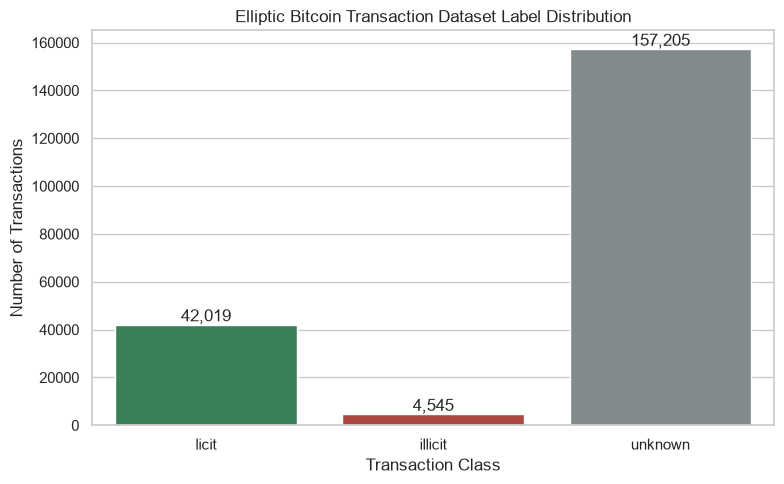

In [12]:
# A bar chart showing the NUMBER of transactions in each class (licit, illicit, unknown) in Elliptic AML dataset.

plot_summary = (
    label_summary
    .reset_index()
    .rename(columns={"label": "class"})
)

fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    plot_summary,
    x="class",
    y="count",
    hue="class",
    palette=LABEL_COLORS,
    legend=False,
    ax=ax
)

# Add value count labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")

ax.set(
    title="Elliptic Bitcoin Transaction Dataset Label Distribution",
    xlabel="Transaction Class",
    ylabel="Number of Transactions"
)

plt.tight_layout()
plt.show()

In [13]:
# Analyze labels over time
time_label_count = (
    transaction_df
    .groupby(["time_step", "label"], observed=True)
    .size() # count the number of transactions for each time_step
    .unstack(fill_value=0) # convert rows to columns to create a DataFrame with time_step 
    .reindex(columns=LABEL_ORDER, fill_value=0) # ensure the columns are in the order of LABEL_ORDER
)

# Separate DataFrame containing the same information.
time_summary = time_label_count.copy()

# Column # 1
time_summary["total"] = time_label_count.sum(axis=1)

# Column # 2
time_summary["labeled"] = (
    time_label_count["licit"] + time_label_count["illicit"]
)

# Column # 3
time_summary["label_coverage_pct"] = (
    time_summary["labeled"] / time_summary["total"] * 100
)

# Column # 4
time_summary["illicit_rate_labeled_pct"] = (
    time_summary["illicit"] / time_summary["total"] * 100
)

display(time_summary)

label,licit,illicit,unknown,total,labeled,label_coverage_pct,illicit_rate_labeled_pct
time_step,,,,,,,
1,2130,17,5733,7880,2147,27.246193,0.215736
2,1099,18,3427,4544,1117,24.581866,0.396127
3,1268,11,5342,6621,1279,19.317324,0.166138
4,1410,30,4253,5693,1440,25.294221,0.526963
5,1874,8,4921,6803,1882,27.664266,0.117595
6,480,5,3843,4328,485,11.206100,0.115527
7,1101,102,4845,6048,1203,19.890873,1.686508
8,1098,67,3292,4457,1165,26.138658,1.503253
9,530,248,4218,4996,778,15.572458,4.963971


C:\Users\Pc Planet\AppData\Local\Temp\ipykernel_23012\4119542624.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
C:\Users\Pc Planet\AppData\Local\Temp\ipykernel_23012\4119542624.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


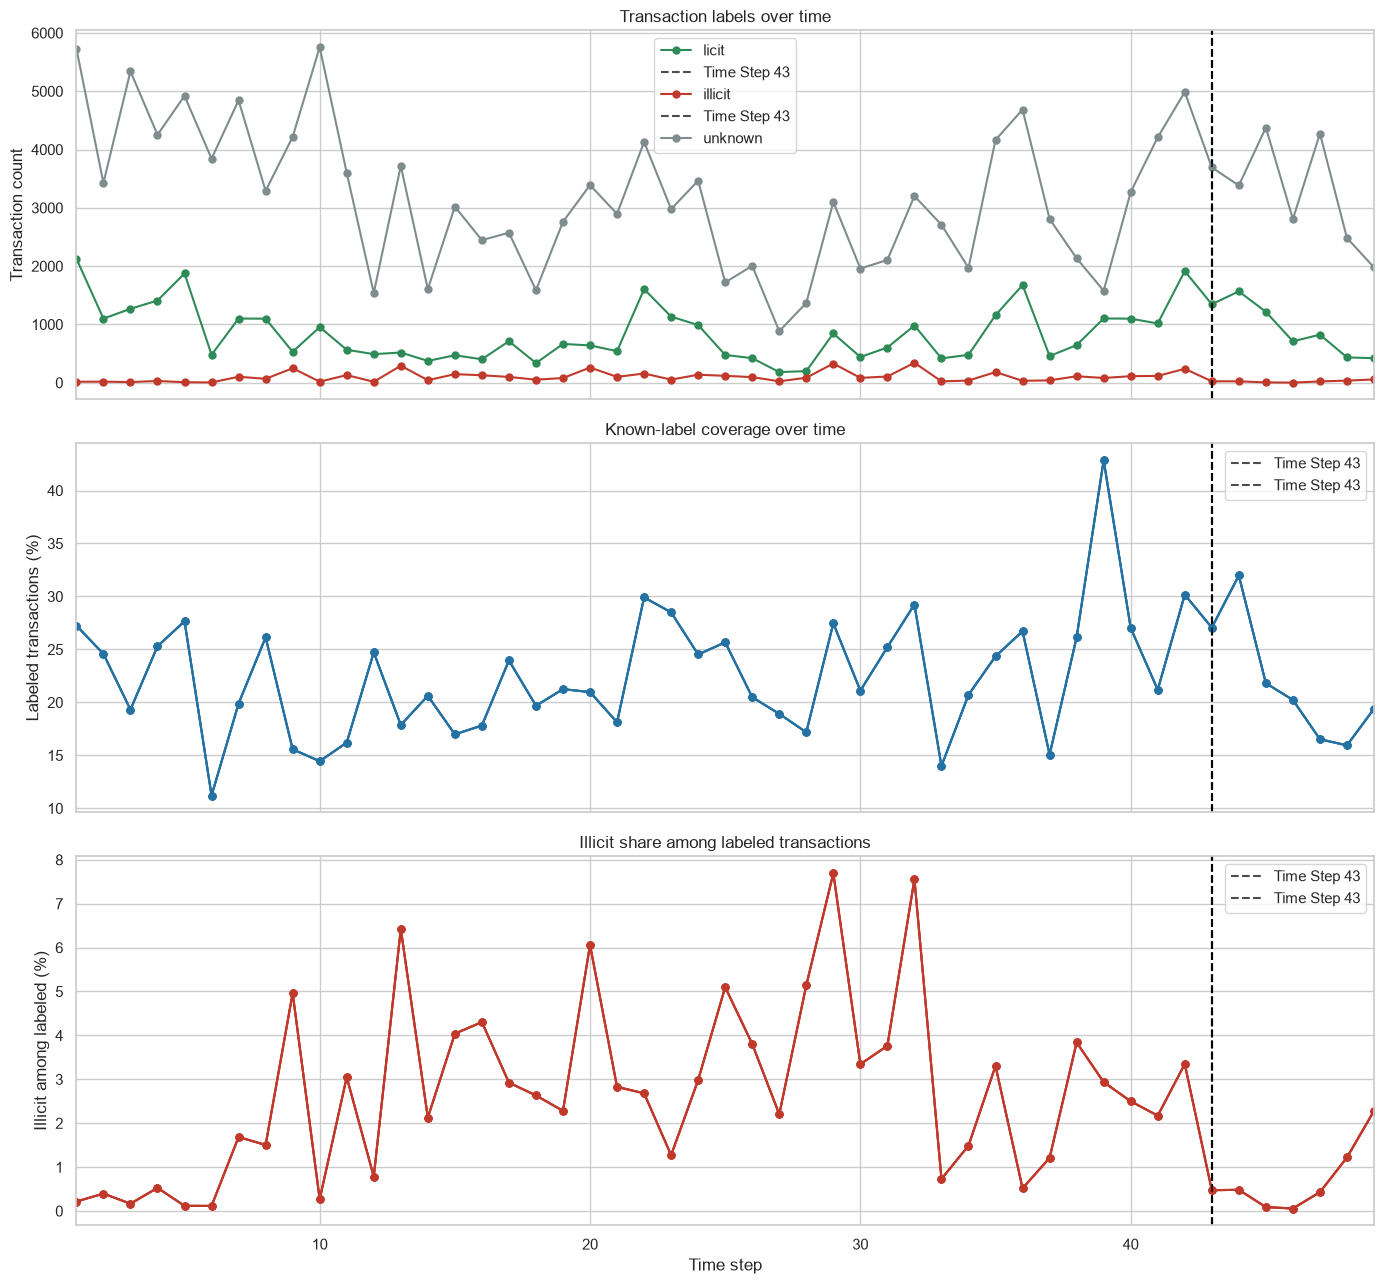

In [14]:
# Create three temporal plots

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14,13),
    sharex=True
)

for label in LABEL_ORDER:
    # Plot: 1
    axes[0].plot(
        time_label_count.index,
        time_label_count[label],
        marker="o",
        markersize=5,
        label=label,
        color=LABEL_COLORS[label]
    )
    axes[0].set(
        title="Transaction labels over time",
        ylabel="Transaction count",
    )
    axes[0].legend()

    # Plot: 2
    axes[1].plot(
        time_summary.index,
        time_summary["label_coverage_pct"],
        color="#2471A3",
        marker="o",
        markersize=5
    )
    axes[1].set(
        title="Known-label coverage over time",
        ylabel="Labeled transactions (%)"
    )
    axes[1].legend()

    # Plot: 3
    axes[2].plot(
        time_summary.index,
        time_summary["illicit_rate_labeled_pct"],
        color=LABEL_COLORS["illicit"],
        marker="o",
        markersize=5
    )

    axes[2].set(
        title="Illicit share among labeled transactions",
        xlabel="Time step",
        ylabel="Illicit among labeled (%)",
    )
    axes[2].legend()

    for ax in axes:
        ax.axvline(
            43,
            color="black",
            linestyle="--",
            alpha=0.7,
            label="Time Step 43"
        )
    ax.set_xlim(1, 49)
plt.tight_layout()
plt.show()


In [15]:
# Examine feature summaries and correlations
# In this Crypto AML Transaction Monitoring System, its purpose is to understand the numerical features 
# before using them for machine learning—especially their scale, distribution, and missing values.

CONTINUOUS_FEATURE_COLUMNS = (
    LOCAL_TRANSACTION_COLUMNS + AGGREGATE_FEATURE_COLUMNS
)

feature_summary = (
    transaction_df[CONTINUOUS_FEATURE_COLUMNS]
    .describe()
    .transpose()
)

feature_summary["missing"] = (
    transaction_df[CONTINUOUS_FEATURE_COLUMNS]
    .isna()
    .sum()
)

# Display the 15 features with highest standard deviation
display(
    feature_summary
    .sort_values("std", ascending=False)
    .head(15)
)

,count,mean,std,min,25%,50%,75%,max,missing
local_feature_020,203769.0,-1.078312e-08,1.000003,-1.373657,-1.373657,0.887058,0.887058,0.887058,0
local_feature_071,203769.0,1.198124e-09,1.000003,-0.030026,-0.030026,-0.030026,-0.030026,137.851868,0
local_feature_073,203769.0,-1.198124e-09,1.000003,-0.015071,-0.015071,-0.015071,-0.015071,151.035172,0
local_feature_093,203769.0,-3.145077e-08,1.000003,-1.084845,-1.084845,0.025217,1.135279,1.135279,0
local_feature_063,203769.0,-1.677374e-08,1.000003,-1.315388,-1.315388,0.475331,0.923011,0.923011,0
aggregate_feature_022,203769.0,-1.916999e-08,1.000003,-1.772828,-1.230441,0.396719,0.939106,2.566266,0
aggregate_feature_032,203769.0,2.396249e-09,1.000003,-0.145126,-0.143707,-0.143707,-0.142288,18.455158,0
aggregate_feature_057,203769.0,-1.437749e-08,1.000003,-1.059868,-1.059868,-0.453330,0.759748,3.185904,0
aggregate_feature_059,203769.0,7.188747e-09,1.000003,-1.116918,-1.116918,0.185597,0.475920,1.488113,0
local_feature_010,203769.0,3.744139e-10,1.000002,-0.049707,-0.049707,-0.049707,-0.049707,189.186951,0


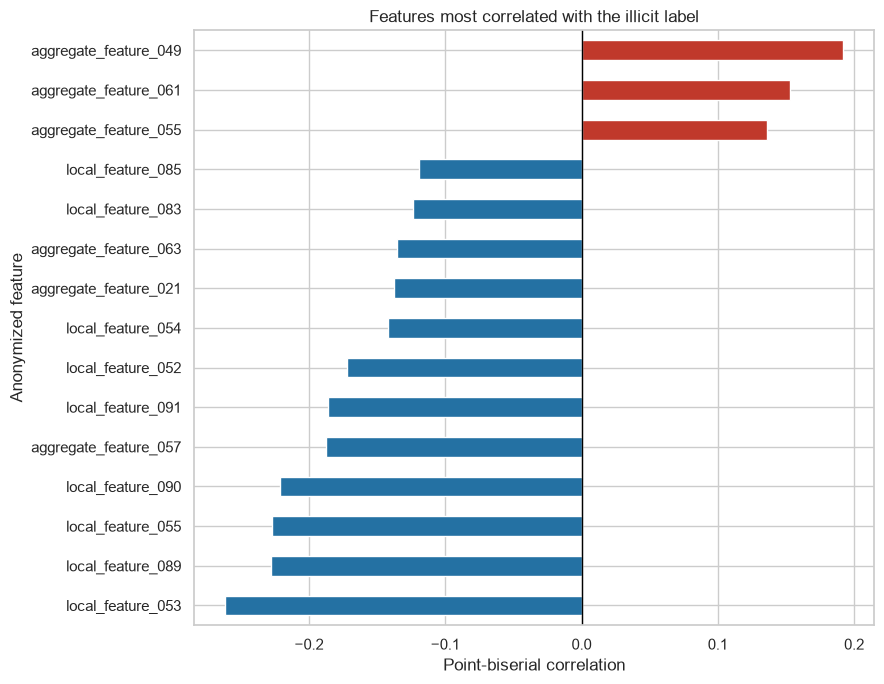

In [16]:
# Measure descriptive correlation with the "illicit" label

# Convert illicit into a binary target
illicit_target = (
    labeled_df["label"]
    .eq("illicit") # ass boolean (T,F)
    .astype("int8") # as binary (0,1)
)

# Calculate correlation between features and illicit target
feature_label_correlations = (
    labeled_df[CONTINUOUS_FEATURE_COLUMNS]
    .corrwith(illicit_target)
    .dropna() # removes features where the correlation result is NaN.
)

# Select the 15 strongest correlations
top_correlations = (
    feature_label_correlations
    .loc[
        feature_label_correlations
        .abs()
        .nlargest(15)
        .index
    ]
    .sort_values()
)
# display(top_correlations)

# Create the chart
fig, ax = plt.subplots(figsize=(9,7))

top_correlations.plot(
    kind="barh",
    color=[
        LABEL_COLORS["illicit"] if value > 0 else "#2471A3"
        for value in top_correlations
    ],
    ax=ax,
)

ax.set(
    title="Features most correlated with the illicit label",
    xlabel="Point-biserial correlation",
    ylabel="Anonymized feature",
)

ax.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

These correlations are descriptive only. 

We will not use this full-dataset ranking for model feature selection, because it includes future time periods.

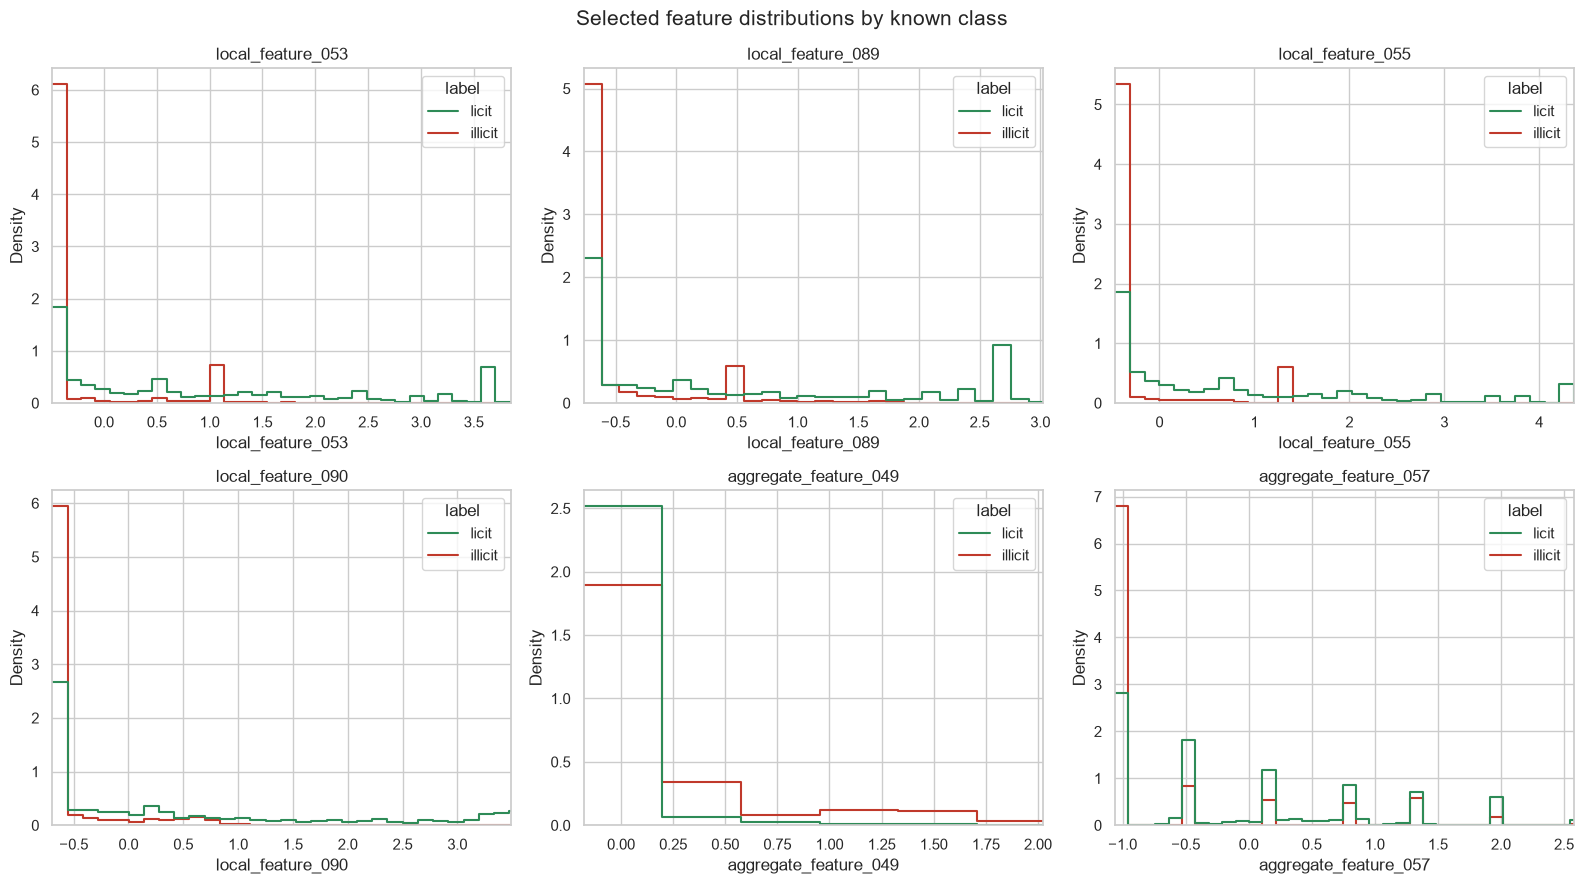

In [17]:
# Plot selected feature distributions

selected_features = (
    feature_label_correlations
    .abs()
    .nlargest(6)
    .index
    .tolist() # Return a list of the values.
)

plot_samples = []

# Select rows belonging to each class [i.e. "licit", "illicit"]
for label in ["licit", "illicit"]:
    class_rows = labeled_df.loc[labeled_df["label"] == label]

    # Randomly sample transactions
    plot_samples.append(
        class_rows.sample(
            n=min(5_000, len(class_rows)),
            random_state=RANDOM_SEED
        )
    )

feature_plot_df = pd.concat(
    plot_samples,
    ignore_index=True,
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9)
)

# Loop through features and plots
for feature, ax in zip(selected_features, axes.flat):
    lower, upper = labeled_df[feature].quantile([0.01, 0.99]) # used to control the visible X-axis range.

    sns.histplot(
        data=feature_plot_df,
        x=feature,
        hue="label",
        hue_order=["licit", "illicit"],
        palette=LABEL_COLORS,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax
    )

    ax.set_xlim(lower, upper)
    ax.set_title(feature)

    fig.suptitle(
        "Selected feature distributions by known class",
        fontsize=15,
        )

plt.tight_layout()
plt.show()

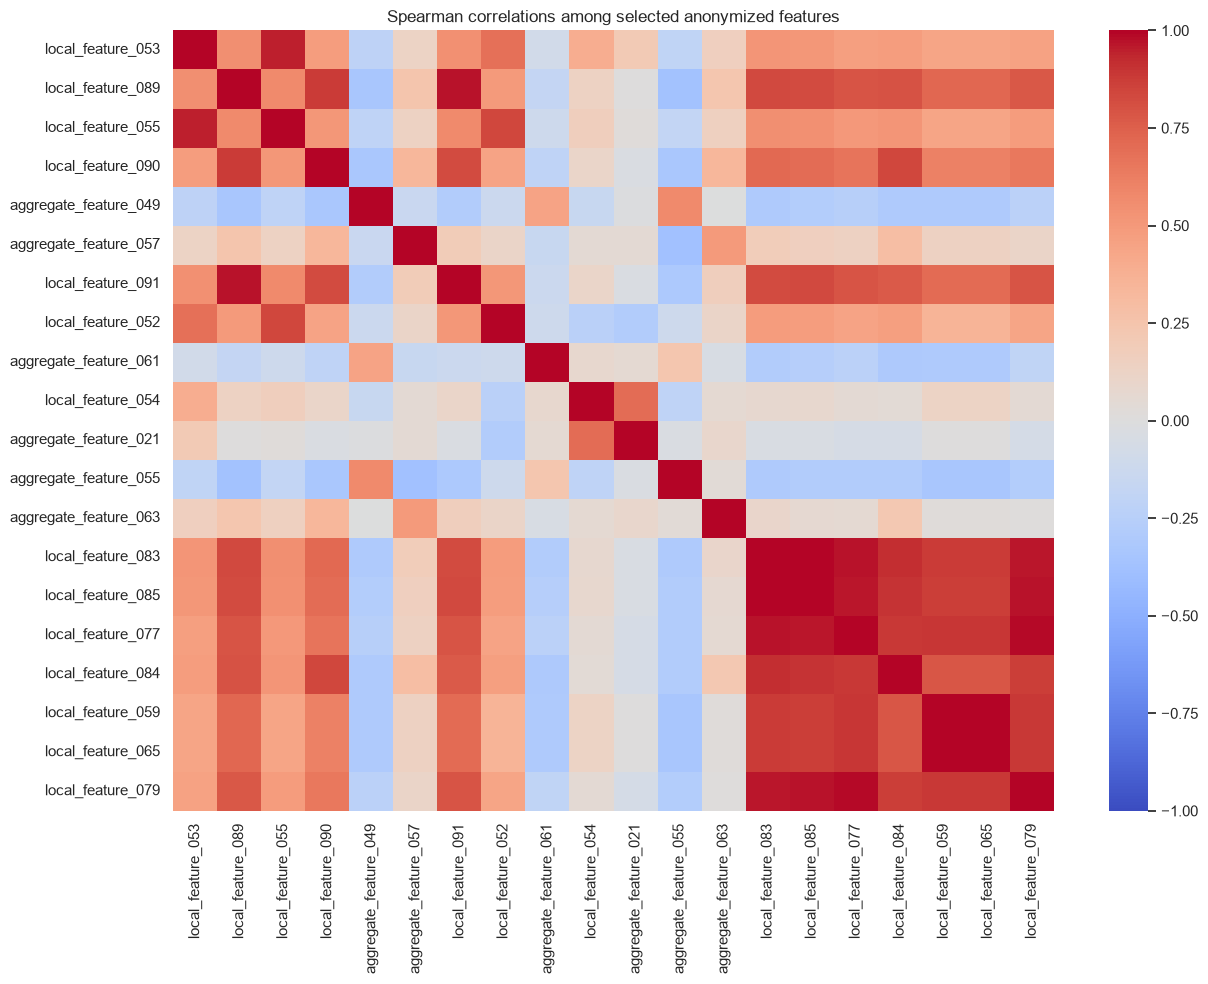

In [18]:
# For feature-to-feature relationships:
# This code performs feature-to-feature correlation analysis 
# on the 20 continuous features most strongly associated with the illicit label.

# Its purpose is different from your previous correlation code:

# Previous section: feature ↔ illicit target
# This code: feature ↔ feature

# This helps identify redundant features, highly related variables, 
# and possible multicollinearity before ML modeling.
correlation_features = (
    feature_label_correlations
    .abs()
    .nlargest(20)
    .index
)

# Why use Spearman here?
# This is useful for transaction data because financial/blockchain features can be:
# highly skewed
# affected by extreme values
# non-normally distributed
# Spearman can therefore be useful for detecting monotonic relationships that aren't necessarily linear.
feature_correlation_matrix = (
    labeled_df[correlation_features]
    # Spearman correlation measures whether two variables 
    # have a monotonic relationship.
    .corr(method="spearman")
)

# display(feature_correlation_matrix)
fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    feature_correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)

ax.set_title(
    "Spearman correlations among selected anonymized features"
)

plt.tight_layout()
plt.show()

## Transaction Graph Analysis

### Calculate graph statistics
In this Crypto AML project, the transaction data is represented as a **directed graph**:

1. **Each transaction is represented as a node.**
2. **Each transaction-to-transaction relationship is represented as a directed edge.**

The graph analysis calculates several important network statistics.

### 1. In-Degree

**In-degree** measures the number of edges entering a node.

For example:

```text
A ───→ B
```

Transaction `B` has an **in-degree of 1** because one edge enters `B`.

If:

```text
A ───→ C
B ───→ C
D ───→ C
```

then:

```text
C has an in-degree of 3
```

---

### 2. Out-Degree

**Out-degree** measures the number of edges leaving a node.

For example:

```text
A ───→ B
A ───→ C
A ───→ D
```

Transaction `A` has an **out-degree of 3** because three edges leave `A`.

---

### 3. Graph Density

**Graph density** measures how many of the possible connections between transactions actually exist.

* Density close to `0` → sparse graph with relatively few connections.
* Density close to `1` → highly connected graph.

For a directed graph without self-loops:

```text
Density = Number of edges / [Number of nodes × (Number of nodes − 1)]
```

---

### 4. Isolated Nodes

An **isolated node** is a transaction that does not appear as either a source or a target in any edge.

Therefore, an isolated transaction has:

```text
in-degree  = 0
out-degree = 0
```

---

### 5. Self-Loops

A **self-loop** occurs when a transaction points to itself:

```text
A ───→ A
```

Here, the source and target transaction IDs are identical.

---

### 6. Duplicate Edges

**Duplicate edges** occur when the same edge appears more than once in the dataset.

For example:

```text
A ───→ B
A ───→ B
```

The second edge is a duplicate of the first.

These checks help validate the transaction graph and provide a better understanding of its structure before using graph-based features for AML analysis.


### Graph Density

**Density** measures **how connected your transaction graph is**.

Your code calculates:

```python
density = edge_count / (node_count * (node_count - 1))
```

For a **directed graph**, `node_count × (node_count - 1)` is the maximum possible number of directed edges between different nodes.

### Example

Suppose you have:

* **100 nodes**
* **500 directed edges**

Maximum possible edges:

```text
100 × 99 = 9,900
```

Density:

```text
500 / 9,900 = 0.0505
```

So the graph density is approximately **5.05%**.

### Interpretation

* **Density ≈ 0** → very sparse graph; few connections
* **Density ≈ 1** → extremely dense graph; almost every node connects to every other node

For an **Ethereum transaction graph**, density will usually be **very low**, because there are enormous numbers of possible node-to-node connections but only a relatively small number actually occur.

**In simple terms:**

> Density tells you **what proportion of all possible transaction-to-transaction connections actually exist**.


In [19]:
# Create the list of transaction nodes
node_ids = pd.Index(transaction_df["transaction_id"])

# Calculate in-degree
in_degree = (
    edges_df["target_transaction_id"]
    .value_counts()
    .reindex(node_ids, fill_value=0)
)

# Calculate out-degree
out_degree = (
    edges_df["source_transaction_id"]
    .value_counts()
    .reindex(node_ids, fill_value=0)
)

total_degree = in_degree + out_degree

# This finds every transaction ID that appears anywhere in the edges.
edge_endpoint_ids = pd.Index(
    pd.concat([
        edges_df["source_transaction_id"],
        edges_df["target_transaction_id"]
    ],
    ignore_index=True,
    ).unique()
)

node_count = len(node_ids)
edge_count = len(edges_df)

graph_summary = pd.Series({
    "nodes": node_count,
    "directed_edges": edge_count,
    "density": edge_count / (node_count * (node_count - 1)),
    "isolated_nodes": len(node_ids.difference(edge_endpoint_ids)),
    "zero_in_degree_nodes": int((in_degree == 0).sum()),
    "zero_out_degree_nodes": int((out_degree == 0).sum()),
    "mean_in_degree": in_degree.mean(),
    "mean_out_degree": out_degree.mean(),
    "maximum_in_degree": int(in_degree.max()),
    "maximum_out_degree": int(out_degree.max()),
    "self_loops": int(
        (
            edges_df["source_transaction_id"] ==
            edges_df["target_transaction_id"]
        ).sum()
    ),
    "duplicate_edges": int(edges_df.duplicated().sum()),
})

display(graph_summary.to_frame("value"))

,value
nodes,203769.000000
directed_edges,234355.000000
density,0.000006
isolated_nodes,0.000000
zero_in_degree_nodes,55322.000000
zero_out_degree_nodes,37424.000000
mean_in_degree,1.150101
mean_out_degree,1.150101
maximum_in_degree,284.000000
maximum_out_degree,472.000000


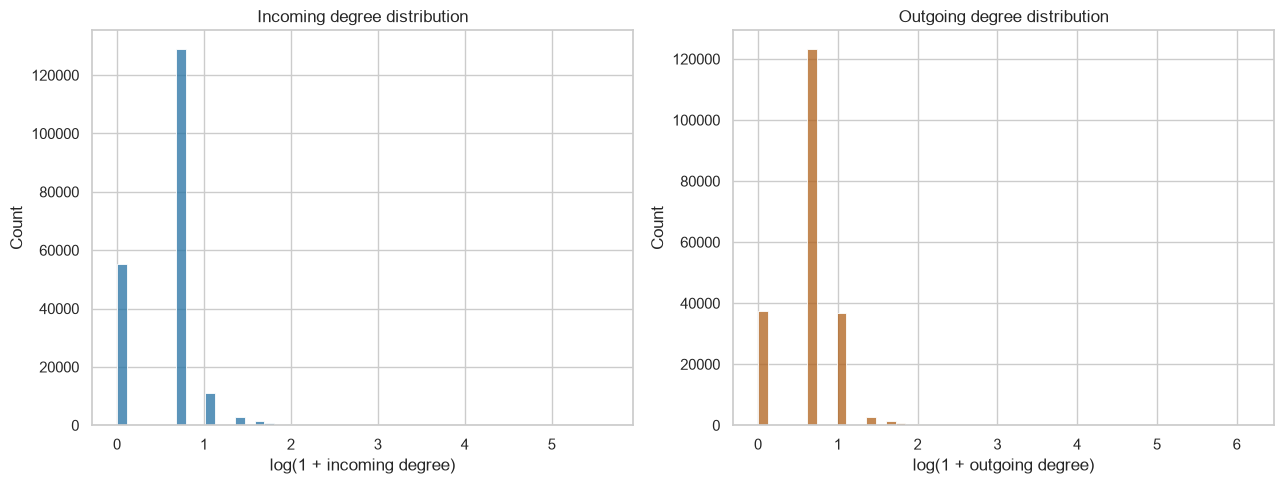

In [20]:
# Plot the heavy-tailed degree distributions:

fig, axes = plt.subplots(1,2, figsize=(13,5))

sns.histplot(
    np.log1p(in_degree),
    bins=50,
    ax=axes[0],
    color="#2471A3",
)

axes[0].set(
    title="Incoming degree distribution",
    xlabel="log(1 + incoming degree)"
)

sns.histplot(
    np.log1p(out_degree),
    bins=50,
    ax=axes[1],
    color="#AF601A"
)

axes[1].set(
    title="Outgoing degree distribution",
    xlabel="log(1 + outgoing degree)"
)

plt.tight_layout()
plt.show()

In [21]:
# Check the temporal consistency of edges

# Create a transaction → time-step mapping
time_by_transaction = (
    transaction_df
        .set_index("transaction_id") # set the "transaction Id" as index
        ["time_step"] # select omnly "Time_step" column
    )

# Find the time step of each source transaction
source_time = (
    edges_df["source_transaction_id"]
    .map(time_by_transaction)
)

# Find the time step of each target transaction
target_time = (
    edges_df["target_transaction_id"]
    .map(time_by_transaction)
)

# Count cross-time edges
cross_time_edges = int((source_time != target_time).sum())

print(f"Edges joining different time steps: {cross_time_edges:,}")
# The canonical data should report zero cross-time edges.
# Edges joining different time steps: 0


Edges joining different time steps: 0


### Investigate time step 43

Why investigate time step 43?

The important observation is:

 - Time 42 → ~11.10% illicit
 - Time 43 → ~1.75% illicit
 - Following steps → unusually low

This could indicate several things:

- A genuine change in transaction behavior
- A change in the underlying data
- A labeling/data-collection issue
- A change in how transactions were classified
- A temporal/data-boundary effect

In [22]:
display(
    time_summary.loc[
        41:45,
        ["licit",
         "illicit",
         "unknown",
         "labeled",
         "label_coverage_pct",
         "illicit_rate_labeled_pct",],
    ].round(3)
)
# print(time_summary.columns.tolist())

label,licit,illicit,unknown,labeled,label_coverage_pct,illicit_rate_labeled_pct
time_step,,,,,,
41,1016,116,4210,1132,21.191,2.171
42,1915,239,4986,2154,30.168,3.347
43,1346,24,3693,1370,27.059,0.474
44,1567,24,3384,1591,31.980,0.482
45,1216,5,4377,1221,21.811,0.089


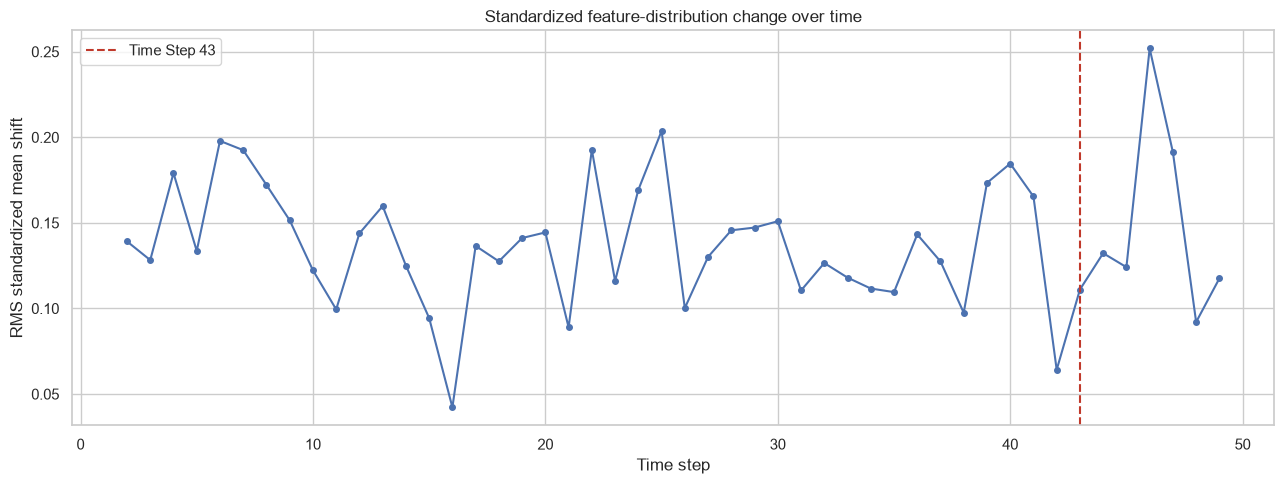

In [23]:
# This code measures how much the average transaction-feature profile changes from 
# one time step to the next, after standardizing each feature by its overall standard deviation.

# Calculates the overall standard deviation of every continuous feature.
global_feature_std = (
    transaction_df[CONTINUOUS_FEATURE_COLUMNS]
    .std()
    .replace(0, np.nan)
)

# calculates the mean of every feature for every time step.
time_feature_means = (
    transaction_df
    .groupby("time_step")[CONTINUOUS_FEATURE_COLUMNS]
    .mean()
)

# Calculates the changes between consecutive time steps.
standardized_centroid_shift = (
    time_feature_means
    .diff() # change from the previous time step
    .div(global_feature_std) # divides each feature's change by its global standard deviation.
    .pow(2) # Raises value to *2, remove +/-
    .mean(axis=1)
    .pow(0.5)
)
# display(standardized_centroid_shift)

fig, ax = plt.subplots(figsize=(13,5))

ax.plot(
    standardized_centroid_shift.index,
    standardized_centroid_shift,
    marker="o",
    markersize=4,
)

# Mark time step 43
ax.axvline(
    43,
    color=LABEL_COLORS["illicit"],
    linestyle="--",
    label="Time Step 43"
)

ax.set(
    title="Standardized feature-distribution change over time",
    xlabel="Time step",
    ylabel="RMS standardized mean shift",
)
ax.legend()

plt.tight_layout()
plt.show()

,absolute_standardized_mean_shift
local_feature_002,0.727619
aggregate_feature_050,0.404300
aggregate_feature_051,0.389778
aggregate_feature_052,0.335584
aggregate_feature_016,0.283492
aggregate_feature_015,0.277449
aggregate_feature_014,0.273896
local_feature_052,0.243474
aggregate_feature_013,0.219579
local_feature_055,0.208686


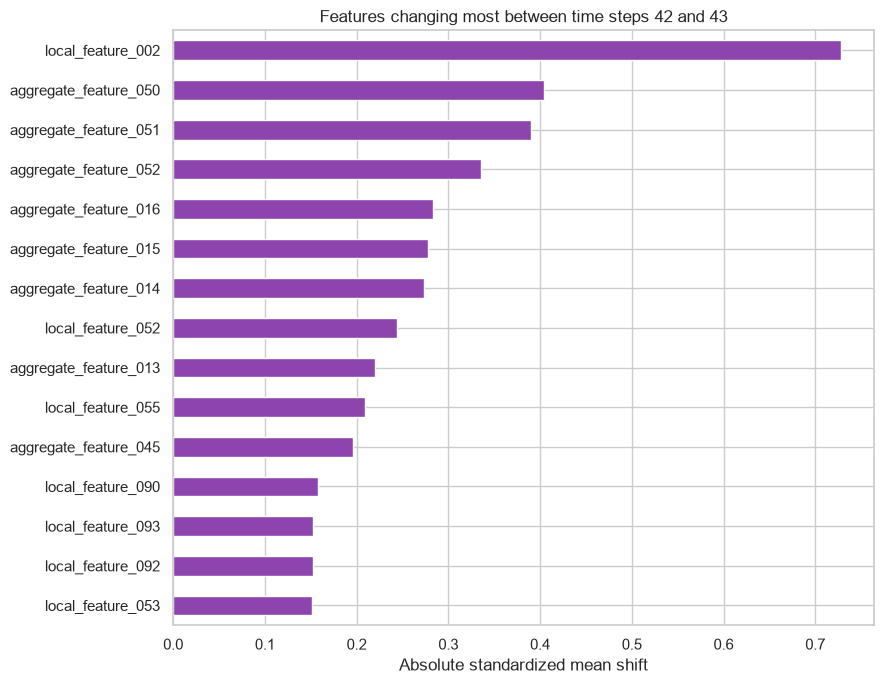

In [24]:
# This code performs a feature-level investigation of the change from time step 42 to 43.
# The previous code told us whether the overall feature distribution changed.
# This code tells:
# Which specific features changed the most between time steps 42 and 43?


# Calculate feature changes from 42 → 43
feature_shift_42_to_43 = (
    (
        time_feature_means.loc[43] -
        time_feature_means.loc[42]
    )
    .div(global_feature_std)
    .abs()
    .sort_values(ascending=False)
    .head(15)
)
display(
    feature_shift_42_to_43
    .rename("absolute_standardized_mean_shift")
    .to_frame()
    )

fig, ax = plt.subplots(figsize=(9, 7))

feature_shift_42_to_43.sort_values().plot(
    kind="barh",
    color="#8E44AD",
    ax=ax
)

ax.set(
    title="Features changing most between time steps 42 and 43",
    xlabel="Absolute standardized mean shift",
)

plt.tight_layout()
plt.show()

### EDA findings and limitations

- Only about 22.85% of transactions have known labels.
- Illicit transactions represent about 9.76% of labeled transactions and
  2.23% of the complete dataset.
- Unknown transactions cannot be treated as legitimate examples.
- Label prevalence and coverage change substantially across time.
- The illicit share drops sharply at time step 43, indicating temporal drift.
- The graph is sparse and directed, with a small average degree and a few
  comparatively high-degree transactions.
- All observed edges connect transactions within the same time step.
- Features are anonymized, so statistical importance cannot automatically be
  translated into compliance explanations.
- Correlations observed here do not establish causation.
- Full-dataset EDA must not be used for model selection; preprocessing and
  feature selection will be fitted only on the appropriate training periods.

## 4. Leakage-safe dataset preparation

Only transactions with known labels are used for supervised modeling.

Data is divided chronologically so that preprocessing, model training,
calibration, threshold selection, and final testing use separate time periods.
Unknown transactions remain in the original transaction table for later
exploratory scoring.

In [25]:
# Creating the supervised target

# Map licit transactions to 0 and illicit transactions to 1:
TARGET_MAP = {
    "licit": 0,
    "illicit": 1
}

# We only want transactions with labels that model understands.
# creates an independent copy
supervised_df = (
    transaction_df.loc[transaction_df["label"].isin(TARGET_MAP)].copy()
)

# Creating the target column
supervised_df["target"] = (
    supervised_df["label"]
    .astype("string")
    .map(TARGET_MAP)
    .astype("uint8")
)

print(f"All Transactions: {len(transaction_df)}")
print(f"Supervised Transactions: {len(supervised_df)}")
print(f"Excluded UNKNOWN rows: {len(transaction_df) - len(supervised_df)}")

display(supervised_df["target"].value_counts().rename(index={0: "licit", 1: "illicit"}).to_frame("count"))




All Transactions: 203769
Supervised Transactions: 46564
Excluded UNKNOWN rows: 157205


,count
target,
licit,42019
illicit,4545


In [26]:
# Define the two feature variants
# The local variant contains the time step and 93 local features. 
# The full variant adds 72 aggregate features.

LOCAL_MODEL_FEATURES = (
    "time_step",
    *LOCAL_TRANSACTION_COLUMNS
)

ALL_MODEL_FEATURES = (
    *LOCAL_MODEL_FEATURES,
    *AGGREGATE_FEATURE_COLUMNS,
)

FEATURE_SETS = {
    "local_94": LOCAL_MODEL_FEATURES,
    "all_166": ALL_MODEL_FEATURES
}

print(f"Local feature count: {len(LOCAL_MODEL_FEATURES)}")
print(f"All feature count:   {len(ALL_MODEL_FEATURES)}")

Local feature count: 94
All feature count:   166


In [27]:
# Validate the feature contracts
require(
    len(LOCAL_MODEL_FEATURES) == 94,
    "the local feature variant must contain 94 features",
)

require(
    len(ALL_MODEL_FEATURES) == 166,
    "the complete feature variant must contain 166 features",
)

require(
    tuple(ALL_MODEL_FEATURES) == tuple(NODE_FEATURE_COLUMNS),
    "the complete feature variant does not match the validated node schema",
)

for excluded_column in [
    "transaction_id",
    "label",
    "target",]:

    # EXCLUDED_COLUMNS must not be used in model training
    require(
        excluded_column not in ALL_MODEL_FEATURES,
        f"{excluded_column!r} must not be used as a model feature",
    )

    # Checking for duplicate columns
    require(
        len(set(ALL_MODEL_FEATURES)) == len(ALL_MODEL_FEATURES),
        "the feature list contains duplicate columns",
    )
    
# display(len(ALL_MODEL_FEATURES))
# display(len(NODE_FEATURE_COLUMNS))

### Create the chronological partitions
This code divides labelled transaction dataset into four time-based partitions:
1. Training
2. Calibration
3. Threshold validation
4. Test
-------------------------

| Partition | Time steps | Permitted use |
|---|---:|---|
| Training | 1–25 | Fit preprocessing and models; internal temporal tuning |
| Calibration | 26–30 | Fit probability calibration after fixing the base model |
| Threshold validation | 31–34 | Select the alert threshold and final candidate |
| Test | 35–49 | Final evaluation only |

In [28]:
# Instead of randomly splitting
# Create the chronological partitions
PARTITION_ORDER = [
    "training",
    "calibration",
    "threshold_validation",
    "test",
]

# Create the partition column
# partition column is divided coronological order
supervised_df["partition"] = pd.cut(
    supervised_df["time_step"], # cut time_step into 4
    # Define bin boundaries and corresponding labels
    bins=[0, 25, 30, 34, 49],
    labels=PARTITION_ORDER,
    include_lowest=True, # dont skip lowest value i.e.; 0
    right=True # include the right value of that particulat bin
)

# Validate that every row received a partition label
require(
    supervised_df["partition"].notna().all(),
    "one or more supervised rows were not assigned to a partition",
)
# creates a dictionary containing four separate DataFrames.
partition_frames = {
    partition: (
        supervised_df
        .loc[supervised_df["partition"] == partition]
        .copy()
    )
    for partition in PARTITION_ORDER
}

# print(partition_frames)


In [29]:
# Summarize the partitions
partition_summary = (
    supervised_df
    .groupby(["partition", "label"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=PARTITION_ORDER,
        columns=["licit", "illicit"],
        fill_value=0
    )
)

# createa "total" column
partition_summary["total"] = partition_summary.sum(axis=1)

# "illicite_percentage" column
partition_summary["illicit_pct"] = (
    partition_summary["illicit"] /
    partition_summary["total"] * 100
)
display(partition_summary.round(3))

# The changing illicit percentage is further evidence that 
# random splitting would be misleading.

label,licit,illicit,total,illicit_pct
partition,,,,
training,21863,2337,24200,9.657
calibration,2088,617,2705,22.810
threshold_validation,2481,508,2989,16.996
test,15587,1083,16670,6.497


In [30]:
# This dictionary defines the exact time steps that should belong to each partition.
EXPECTED_PARTITION_TIME_STEPS = {
    "training": set(range(1, 26)),
    "calibration": set(range(26, 31)),
    "threshold_validation": set(range(31, 35)),
    "test": set(range(35, 50)),
}

EXPECTED_PARTITION_COUNTS = {
    "training": {
        "licit": 21_863,
        "illicit": 2_337,
    },
    "calibration": {
        "licit": 2_088,
        "illicit": 617,
    },
    "threshold_validation": {
        "licit": 2_481,
        "illicit": 508,
    },
    "test": {
        "licit": 15_587,
        "illicit": 1_083,
    },
}

# display(EXPECTED_PARTITION_COUNTS)

In [31]:
# Validate each partition
# Go through each dataset partition and make sure
# its contents are exactly what we expect before using it for ML.

for partition, frame in partition_frames.items():
    observed_time_steps = set(
        frame["time_step"].astype(int).unique()
    )

    require(
        observed_time_steps ==
        EXPECTED_PARTITION_TIME_STEPS[partition],
        f"{partition} has incorrect time steps:"
        f"{sorted(observed_time_steps)}"
    )

    observed_counts = (
        frame["label"]
        .value_counts()
        .reindex(["licit", "illicit"], fill_value=0)
        .astype(int)
        .to_dict()
    )

    require(
        observed_counts == EXPECTED_PARTITION_COUNTS[partition],
        f"{partition} has unexpected label counts:"
        f"{observed_counts}"
    )

    require(
        not frame["label"].astype("string").eq("unknown").any(),
        f"{partition} contains unknown labels",
    )

    require(
        set(frame["target"].unique()) <= {0, 1},
        f"{partition} contains an invalid target value",
    )
# display(partition_frames)

In [32]:
# Check chronological ordering
# Take each pair of neighboring partitions. 
# Find the last time step in the earlier partition 
# and the first time step in the later partition.
# Make sure the earlier partition ends strictly 
# before the later partition begins.
# If not, report a chronological overlap

for earlier, later in zip(
    PARTITION_ORDER,
    PARTITION_ORDER[1:],
):
    earlier_max = (
        partition_frames[earlier]["time_step"].max()
    )
    later_min = (
        partition_frames[later]["time_step"].min()
    )

    require(
        earlier_max < later_min,
        f"{earlier} overlaps chronologically with {later}",
    )

In [33]:
# Check transaction-ID disjointness
for left_index, left_name in enumerate(PARTITION_ORDER):
    left_ids = set(
        partition_frames[left_name]["transaction_id"]
    )

    for right_name in PARTITION_ORDER[left_index + 1:]:
        right_ids = set(
            partition_frames[right_name]["transaction_id"]
        )

        overlap = left_ids.intersection(right_ids)

        require(
            not overlap,
            f"{left_name} and {right_name} share "
            f"{len(overlap):,} transaction IDs",
        )

In [34]:
# Check complete assignment
partition_row_total = sum(
    len(frame)
    for frame in partition_frames.values()
)

require(
    partition_row_total == len(supervised_df),
    "partition row counts do not equal the supervised dataset size",
)

require(
    supervised_df["transaction_id"].is_unique,
    "the supervised dataset contains duplicate transaction IDs",
)

print("Chronological partition validation passed.")

Chronological partition validation passed.


### Expected feature-matrix shapes:
| Partition | Local | All |
|---|---:|---:|
| Training | `(24200, 94)` | `(24200, 166)` |
| Calibration | `(2705, 94)` | `(2705, 166)` |
| Threshold validation | `(2989, 94)` | `(2989, 166)` |
| Test | `(16670, 94)` | `(16670, 166)` |

In [35]:
# IMPORTS

from sklearn.impute import SimpleImputer # Handles missing values with mean, medien, etc...
from sklearn.preprocessing import StandardScaler # Standardizes numerical features
from sklearn.pipeline import Pipeline # Chains preprocessing steps together
from sklearn.base import clone # Creates a fresh unfitted copy

In [42]:
# This code defines reusable preprocessing blueprints for linear and tree-based models, 
# then provides a safe way to create a fresh, unfitted copy of the appropriate blueprint
# so preprocessing can be fitted independently on training data without accidentally reusing learned state.

# Create one template for "linear models"
linear_preprocessor_template = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"), # Handling Missing values using Median
    ),
    (
        "scaler",
        StandardScaler() # Standardizes numerical features
    )
])

# Create one template for "tree models"
# Tree-based models generally don't require features to be standardized.
tree_preprocessor_template = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    )
])

PREPROCESSOR_TEMPLATES = {
    "linear": linear_preprocessor_template,
    "tree": tree_preprocessor_template,
}

# defines a function that creates a preprocessing pipeline.
def make_preprocessor(
        model_family: str,
) -> Pipeline:
    """Return a FRESH, UN-FITTED preprocessing pipeline."""

    if model_family not in PREPROCESSOR_TEMPLATES:
        raise KeyError(
            f"Unknown model family {model_family!r}."
            f"Choose from {list(PREPROCESSOR_TEMPLATES)}."
        )
    
    # clone() gives you a fresh estimator with the same configuration,
    # but without the learned state.
    return clone(
        PREPROCESSOR_TEMPLATES[model_family]
    )


In [44]:
# Inspect
print("Linear Preprocessing:")
display(make_preprocessor("linear"))

print("Tree preprocessing:")
display(make_preprocessor("tree"))

Linear Preprocessing:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

Tree preprocessing:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness des

Leakage rules to preserve
- Never fit an imputer or scaler on the complete dataset.
- Never use calibration data for model fitting or hyperparameter selection.
- Never use threshold-validation data to fit model coefficients.
- Never examine test predictions while changing the model.
- Never include transaction_id, label, target, or partition as features.
- Do not apply SMOTE before a chronological split.
- Keep unknown transactions outside supervised modeling.
- Do not select features using the full-dataset EDA correlations.
- Keep the final test partition untouched until final Step.